## GSAT trend patterns

In [1]:
# In[1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# %%
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprocess

In [2]:
import importlib
importlib.reload(data_process)

<module 'src.SAT_function_Obs_Fingerprint' from '/work/mh0033/m301036/OBS_LPS_revision/src/SAT_function_Obs_Fingerprint.py'>

In [3]:
# import src.slurm_cluster as scluster
# client, scluster = scluster.init_dask_slurm_cluster()

In [4]:
def func_mk(x):
    """
    Mann-Kendall test for trend
    """
    results = data_process.mk_test(x)
    slope = results[0]
    p_val = results[1]
    return slope, p_val
 

In [7]:
# Input the MMEM annual mean SAT data
input_model = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/LE_data/'
input_ENS = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/LE_data/ENS'

CanESM_data   = xr.open_mfdataset(input_model + 'tas_CanESM5_annual_ano_1850_2022.nc',chunks = {'run':1})
CESM2_data    = xr.open_mfdataset(input_model + 'tas_CESM2_CMIP6_SMBB_annual_ano_1850_2022.nc',chunks = {'run':1})
IPSL_data     = xr.open_mfdataset(input_model + 'tas_IPSL_CM6A_annual_ano_1850_2022.nc',chunks = {'run':1})
EC_Earth_data = xr.open_mfdataset(input_model + 'tas_EC_Earth3_annual_ano_1850_2022.nc',chunks = {'run':1})
ACCESS_data   = xr.open_mfdataset(input_model + 'tas_ACCESS_annual_ano_1850_2022.nc',chunks = {'run':1})
MPI_ESM_data  = xr.open_mfdataset(input_model + 'tas_MPI_ESM_annual_ano_1850_2022.nc',chunks = {'run':1})
MIROC_data    = xr.open_mfdataset(input_model + 'tas_MIROC6_annual_ano_1850_2022.nc',chunks = {'run':1})


In [8]:
ACCESS_data

<xarray.Dataset>
Dimensions:  (lon: 180, lat: 90, year: 173, run: 40)
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2018 2019 2020 2021 2022
  * run      (run) int64 1 2 3 4 5 6 7 8 9 10 ... 31 32 33 34 35 36 37 38 39 40
    height   float64 ...
Data variables:
    tas      (run, year, lat, lon) float32 dask.array<chunksize=(1, 173, 90, 180), meta=np.ndarray>

In [9]:
CESM2_data

<xarray.Dataset>
Dimensions:      (lon: 180, lat: 90, year: 173, run: 100)
Coordinates:
  * lon          (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat          (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * year         (year) int64 1850 1851 1852 1853 1854 ... 2019 2020 2021 2022
  * run          (run) int64 1 2 3 4 5 6 7 8 9 ... 92 93 94 95 96 97 98 99 100
    realization  (run) object dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    tas          (run, year, lat, lon) float32 dask.array<chunksize=(1, 173, 90, 180), meta=np.ndarray>

In [10]:
# input GSAT time series
input_ts_dir = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/LE_timeseries/'

# GSAT_MMLE_annual = xr.open_dataset(input_ts_dir + 'GMSAT_SMILEs_ENS_annual_timeseries_obtained_basedOn_ModelENS_CESM2_cmip650realizations.nc')
GSAT_MMLE_annual = xr.open_dataset(input_ts_dir + 'GMSAT_SMILEs_ENS_annual_timeseries_obtained_basedOn_ModelENS_CESM2_100realizations.nc')

GSAT_MMLE_annual

<xarray.Dataset>
Dimensions:  (year: 173)
Coordinates:
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2018 2019 2020 2021 2022
    height   float64 ...
Data variables:
    tas      (year) float64 ...

In [11]:
ACCESS_data['tas'].values.shape

(40, 173, 90, 180)

In [12]:
# slope_Forced_signal, intercept_Forced_signal = data_process.linear_regression_single_gmst_multi_sat(
#     GSAT_MMLE_annual['tas'],
#     ACCESS_data['tas'].values)

# # separate the GSAT into forced and internal variability
# lat = ACCESS_data['lat']
# lon = ACCESS_data['lon']
# run = ACCESS_data['run']

# slope_Forced_signal_da = xr.DataArray(slope_Forced_signal, coords=[run,lat, lon], dims=['run','lat', 'lon'])
# intercept_Forced_signal_da = xr.DataArray(intercept_Forced_signal, coords=[run, lat, lon], dims=['run','lat', 'lon'])

In [13]:
# Shared GSAT signal
import os

GSAT = GSAT_MMLE_annual['tas']  # shape: (year)

# Dictionary of SAT DataArrays from different models
SAT_dict = {
    'CanESM5': CanESM_data['tas'],
    'CESM2': CESM2_data['tas'],
    'IPSL_CM6A': IPSL_data['tas'],
    'EC_Earth3': EC_Earth_data['tas'],
    'ACCESS': ACCESS_data['tas'],
    'MPI_ESM': MPI_ESM_data['tas'],
    'MIROC6': MIROC_data['tas'],
    # 'MMEM_annual': MMEM_annual_data['tas']
}

# Output directory
output_dir = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG1/Fingerprint/MMLE_GSAT_based/cesm2_100/'
os.makedirs(output_dir, exist_ok=True)
Slope_dict = {}
for model, sat_ds in SAT_dict.items():
    print(f"Processing regression for {model}...")

    # Extract SAT and coordinates
    SAT = sat_ds.values  # shape: (run, year, lat, lon)
    lat = sat_ds['lat']
    lon = sat_ds['lon']
    run = sat_ds['run']

    # Perform regression
    slope, intercept = data_process.linear_regression_single_gmst_multi_sat(GSAT, SAT)

    # Wrap into DataArrays
    slope_da = xr.DataArray(
        slope,
        coords={'run': run, 'lat': lat, 'lon': lon},
        dims=['run', 'lat', 'lon']
    )
    intercept_da = xr.DataArray(
        intercept,
        coords={'run': run, 'lat': lat, 'lon': lon},
        dims=['run', 'lat', 'lon']
    )

    # Save to NetCDF
    slope_da.to_dataset(name="coefficients").to_netcdf(
        os.path.join(output_dir, f"GSAT_{model}_slope_Beta_coefficients_1850_2022.nc")
    )
    intercept_da.to_dataset(name="intercept").to_netcdf(
        os.path.join(output_dir, f"GSAT_{model}_intercept_Alpha_constants_1850_2022.nc")
    )
    Slope_dict[model] = slope_da
    print(f"Saved: {model}")

Processing regression for CanESM5...
Saved: CanESM5
Processing regression for CESM2...
Saved: CESM2
Processing regression for IPSL_CM6A...
Saved: IPSL_CM6A
Processing regression for EC_Earth3...
Saved: EC_Earth3
Processing regression for ACCESS...
Saved: ACCESS
Processing regression for MPI_ESM...
Saved: MPI_ESM
Processing regression for MIROC6...
Saved: MIROC6


In [14]:
# saving the each model's GSAT-based fingerprint results
# Note: The MMEM_annual_data is not included in the SAT_dict as it was commented out in the original code

In [15]:
Slope_dict

{'CanESM5': <xarray.DataArray (run: 50, lat: 90, lon: 180)>
 array([[[2.02404246, 2.02408585, 2.03629262, ..., 1.99319224,
          2.00224319, 2.01246376],
         [1.99581743, 2.00801631, 2.01995013, ..., 1.9642235 ,
          1.97384055, 1.98438416],
         [1.95112345, 1.97054883, 1.98946741, ..., 1.89468667,
          1.91248864, 1.93128969],
         ...,
         [3.07298452, 3.07988818, 3.0869394 , ..., 3.04491426,
          3.05357544, 3.06304933],
         [3.1079639 , 3.11068462, 3.11255814, ..., 3.10209213,
          3.10406757, 3.10605002],
         [3.12592111, 3.12591909, 3.12494714, ..., 3.12719459,
          3.12702831, 3.12668586]],
 
        [[1.96856817, 1.96860203, 1.97846502, ..., 1.9464535 ,
          1.9525338 , 1.95948346],
         [1.95589984, 1.96488323, 1.97404385, ..., 1.93262839,
          1.9396325 , 1.94756238],
         [1.93981576, 1.95381745, 1.96651766, ..., 1.89861466,
          1.91134513, 1.92526474],
 ...
         [3.80122366, 3.8110205 , 3.

In [16]:
# Checking each model's slope DataArray and the minimum and maximum values
for model, slope_da in Slope_dict.items():
    print(f"{model} slope min: {slope_da.min().values}, max: {slope_da.max().values}")
for model, slope_da in Slope_dict.items():
    print(f"{model} slope shape: {slope_da.shape}")
    print(f"{model} slope coordinates: {slope_da.coords}")
    print(f"{model} slope values: {slope_da.values[:5]}")  # Print first 5 values for brevity

CanESM5 slope min: -0.6790324161186551, max: 10.667703531512382
CESM2 slope min: -0.8707349196254552, max: 5.523302728893833
IPSL_CM6A slope min: -1.3705488469028877, max: 9.763897641716087
EC_Earth3 slope min: -2.567077161392975, max: 12.579389287423503
ACCESS slope min: -1.9793860233282328, max: 6.055510180956944
MPI_ESM slope min: -0.9391168037408263, max: 7.4855696447316085
MIROC6 slope min: -2.194461618367036, max: 7.547024145587197
CanESM5 slope shape: (50, 90, 180)
CanESM5 slope coordinates: Coordinates:
  * run      (run) int64 1 2 3 4 5 6 7 8 9 10 ... 41 42 43 44 45 46 47 48 49 50
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
CanESM5 slope values: [[[2.02404246 2.02408585 2.03629262 ... 1.99319224 2.00224319 2.01246376]
  [1.99581743 2.00801631 2.01995013 ... 1.9642235  1.97384055 1.98438416]
  [1.95112345 1.97054883 1.98946741 ... 1.89468667 1.91248864 1.9312896

### Plotting the beta pattern

In [17]:
import src.plot_func as func_plot

# define an asymmetric colormap
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

/tmp/ipykernel_394481/3660455719.py:47: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(contour_obj_for_cbar, cax=cbar_ax, orientation='horizontal', extend=extend)
/tmp/ipykernel_394481/3660455719.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.07, 1, 1])


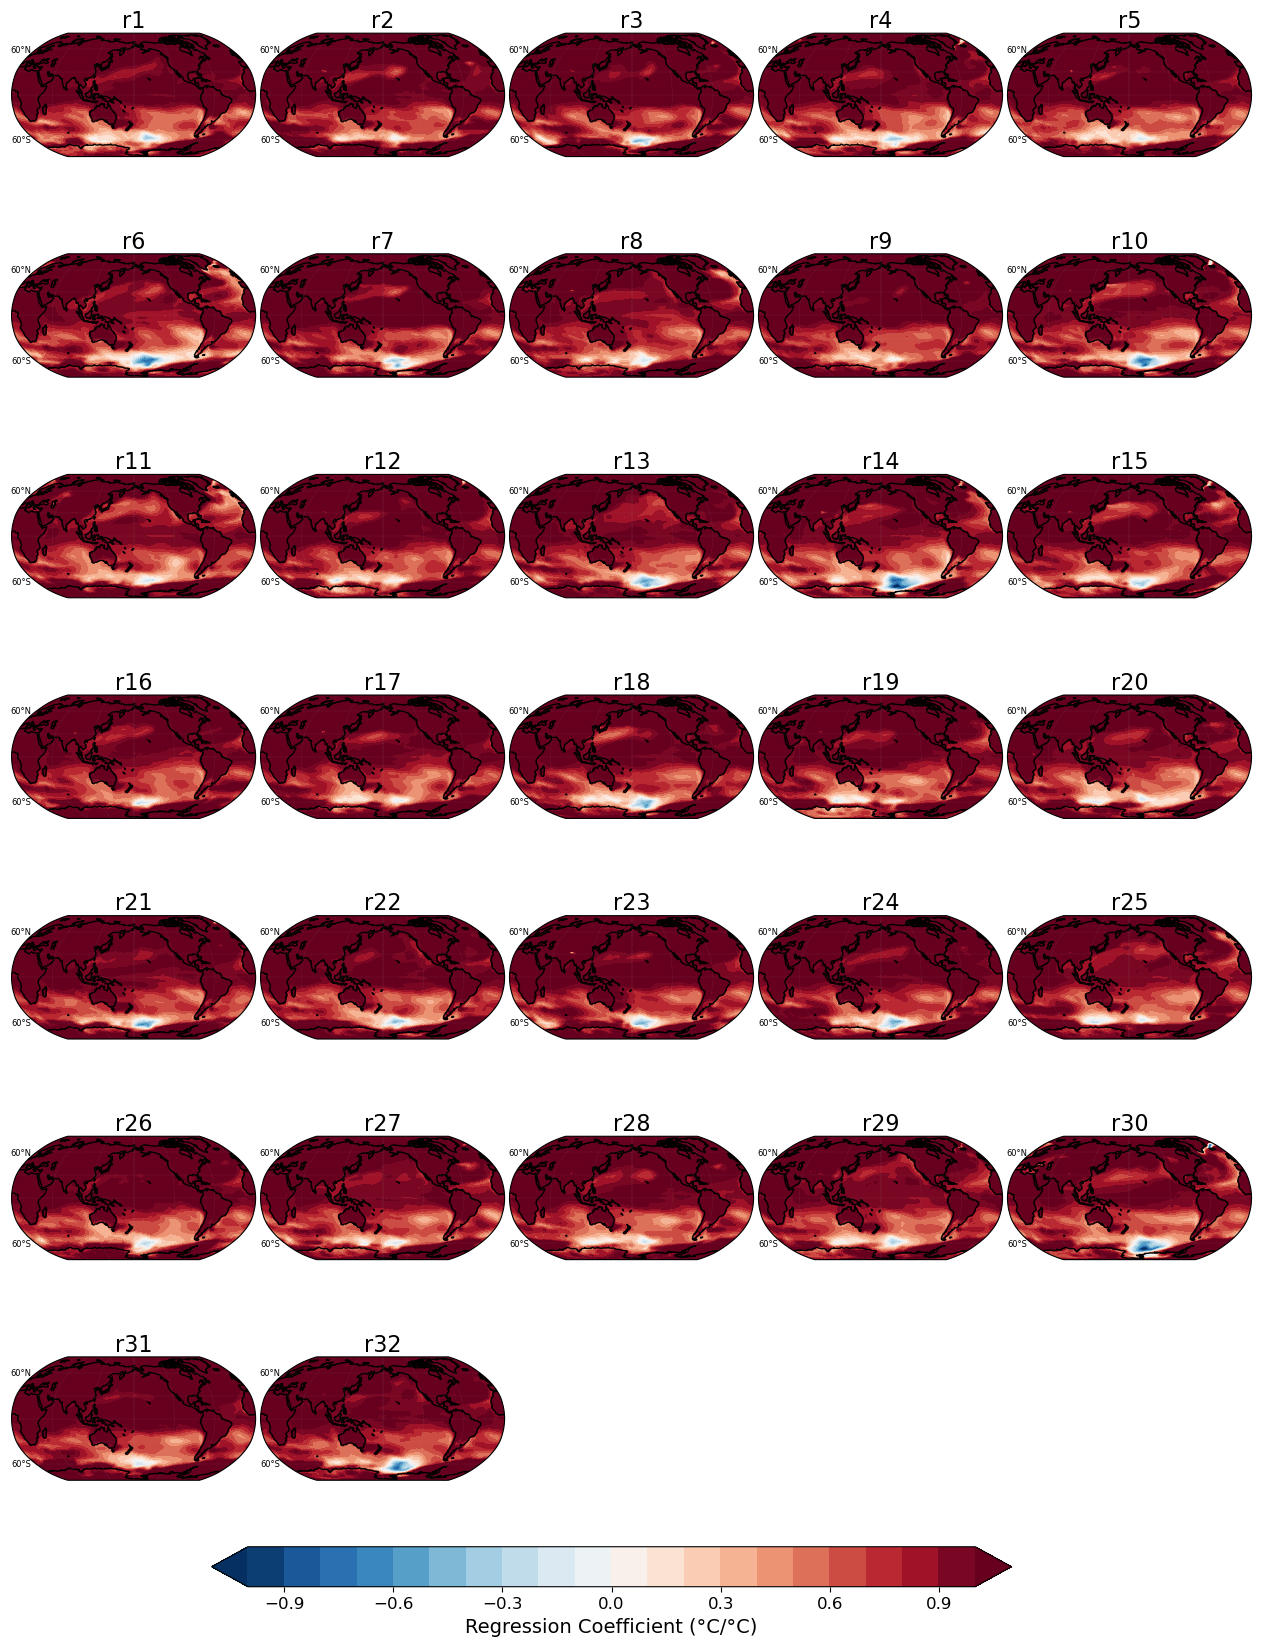

In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.util as cutil
import numpy as np

# === Parameters ===
model_name = "IPSL_CM6A"  # or any other model name you want to use
titles = [f"r{i+1}" for i in range(32)]  # or however many runs you have
levels = np.arange(-1.0, 1.1, 0.1)
extend = 'both'
cmap = 'RdBu_r'

# === Prepare Plot ===
fig = plt.figure(figsize=(16, 20))
ncols = 5
nrows = int(np.ceil(len(titles) / ncols))
gs = gridspec.GridSpec(nrows, ncols, wspace=0.02, hspace=0.02)

# === Loop through and plot each run ===
for i, title in enumerate(titles):
    ax = fig.add_subplot(gs[i], projection=ccrs.Robinson(central_longitude=180))

    run_number = int(title.lstrip('r'))
    beta_data = Slope_dict[model_name].sel(run=run_number)  # Ensure slope_da is defined globally
    beta_cyclic, lon_cyclic = cutil.add_cyclic_point(beta_data, coord=Slope_dict[model_name]['lon'])

    contour_obj = func_plot.plot_data(
        beta_cyclic, Slope_dict[model_name]['lat'], lon_cyclic,
        levels=levels,
        extend=extend,
        cmap=cmap,
        title=" ",
        ax=ax,
        show_xticks=False,
        show_yticks=False
    )

    ax.text(0.5, 1.1, title, transform=ax.transAxes,
            ha='center', va='center', fontsize=16)

    if i == 0:
        contour_obj_for_cbar = contour_obj

# === Add Colorbar ===
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
cbar = plt.colorbar(contour_obj_for_cbar, cax=cbar_ax, orientation='horizontal', extend=extend)
cbar.set_label("Regression Coefficient (°C/°C)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# === Save and Show ===
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(f"{model_name}_beta_pattern.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_394481/3125268048.py:47: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(contour_obj_for_cbar, cax=cbar_ax, orientation='horizontal', extend=extend)
/tmp/ipykernel_394481/3125268048.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.07, 1, 1])


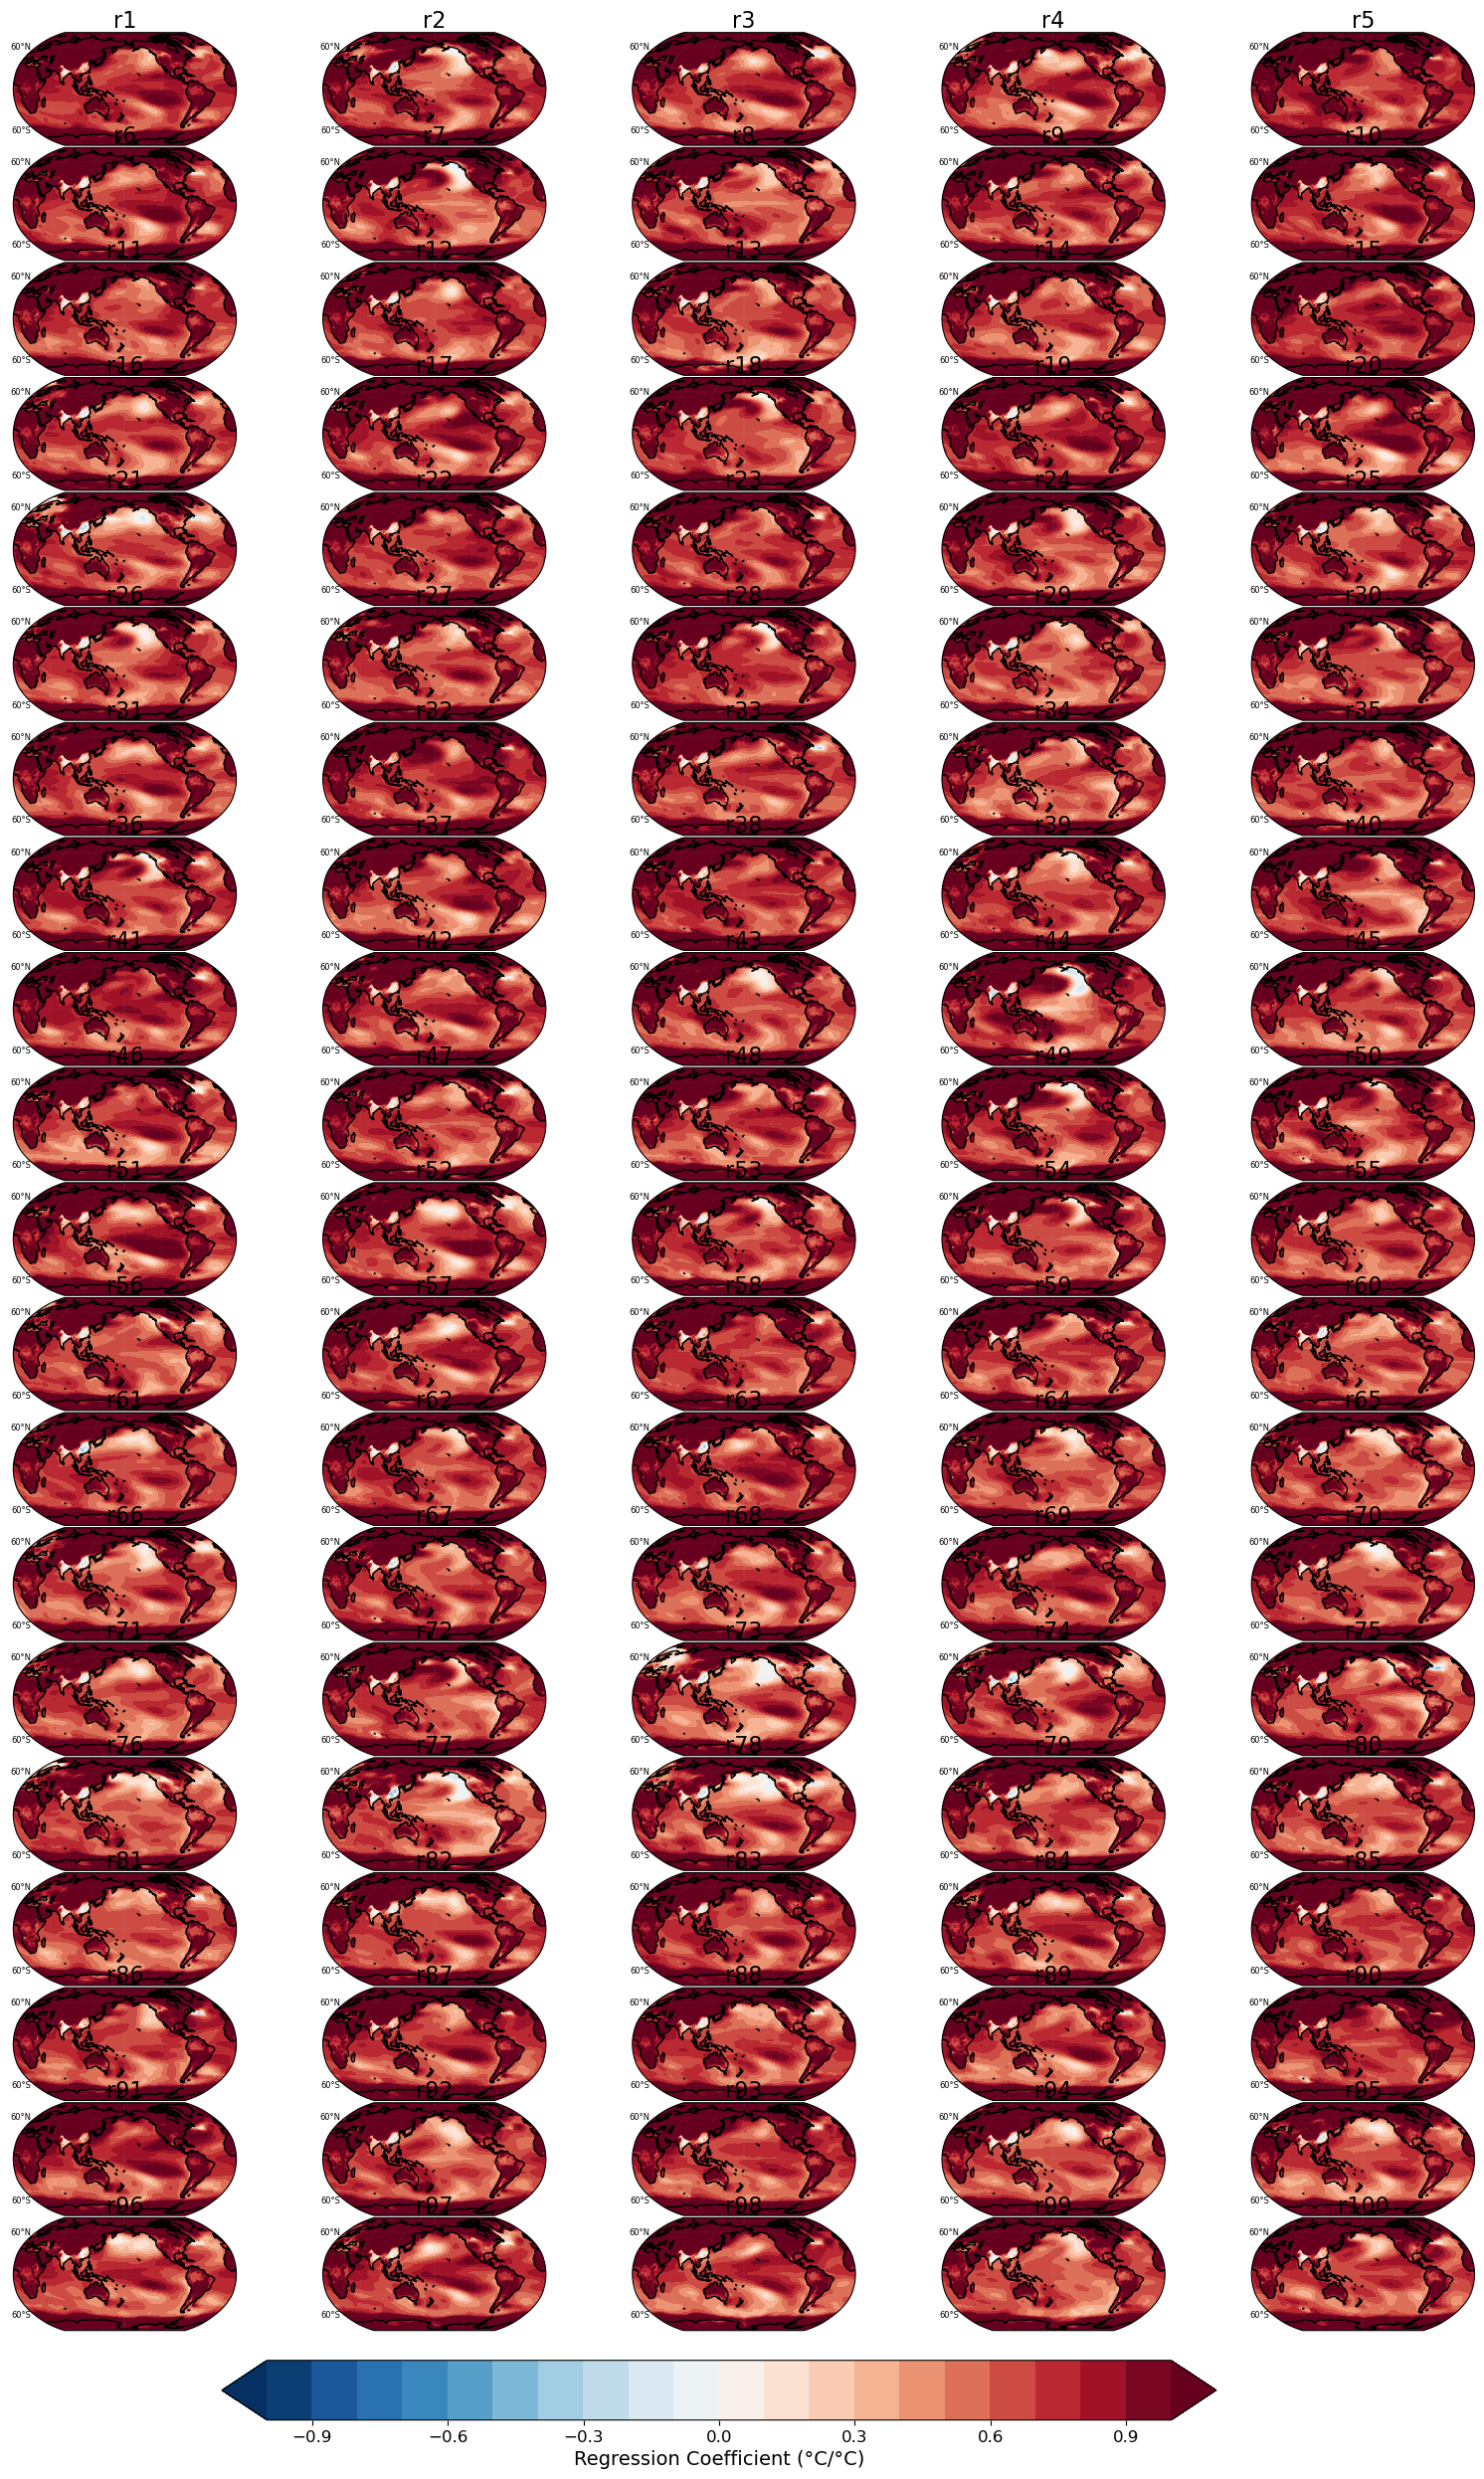

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.util as cutil
import numpy as np

# === Parameters ===
model_name = "CESM2"  # or any other model name you want to use
titles = [f"r{i+1}" for i in range(100)]  # or however many runs you have
levels = np.arange(-1.0, 1.1, 0.1)
extend = 'both'
cmap = 'RdBu_r'

# === Prepare Plot ===
fig = plt.figure(figsize=(20, 30))
ncols = 5
nrows = int(np.ceil(len(titles) / ncols))
gs = gridspec.GridSpec(nrows, ncols, wspace=0.02, hspace=0.02)

# === Loop through and plot each run ===
for i, title in enumerate(titles):
    ax = fig.add_subplot(gs[i], projection=ccrs.Robinson(central_longitude=180))

    run_number = int(title.lstrip('r'))
    beta_data = Slope_dict[model_name].sel(run=run_number)  # Ensure slope_da is defined globally
    beta_cyclic, lon_cyclic = cutil.add_cyclic_point(beta_data, coord=Slope_dict[model_name]['lon'])

    contour_obj = func_plot.plot_data(
        beta_cyclic, Slope_dict[model_name]['lat'], lon_cyclic,
        levels=levels,
        extend=extend,
        cmap=cmap,
        title=" ",
        ax=ax,
        show_xticks=False,
        show_yticks=False
    )

    ax.text(0.5, 1.1, title, transform=ax.transAxes,
            ha='center', va='center', fontsize=16)

    if i == 0:
        contour_obj_for_cbar = contour_obj

# === Add Colorbar ===
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
cbar = plt.colorbar(contour_obj_for_cbar, cax=cbar_ax, orientation='horizontal', extend=extend)
cbar.set_label("Regression Coefficient (°C/°C)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# === Save and Show ===
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(f"{model_name}_beta_pattern.png", dpi=300, bbox_inches='tight')
plt.show()